# 1. Load data

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [2]:
df = pd.read_csv("carclaims.csv")

In [3]:
df.shape

(15420, 33)

In [4]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange-Claim,NumberOfCars,Year,BasePolicy,FraudFound
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability,No
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision,No
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision,No
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability,No
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision,No


# 2. Clean columns names (cleaning)

In [5]:
df.columns = df.columns.str.lower().str.replace('[^a-z0-9]', '_', regex=True)
print(df.columns.tolist())

['month', 'weekofmonth', 'dayofweek', 'make', 'accidentarea', 'dayofweekclaimed', 'monthclaimed', 'weekofmonthclaimed', 'sex', 'maritalstatus', 'age', 'fault', 'policytype', 'vehiclecategory', 'vehicleprice', 'policynumber', 'repnumber', 'deductible', 'driverrating', 'days_policy_accident', 'days_policy_claim', 'pastnumberofclaims', 'ageofvehicle', 'ageofpolicyholder', 'policereportfiled', 'witnesspresent', 'agenttype', 'numberofsuppliments', 'addresschange_claim', 'numberofcars', 'year', 'basepolicy', 'fraudfound']


# 3. Drop Leakage and Useless Columns

In [6]:
drop_cols = [
    'policynumber',
    'repnumber',
    'daysofpolicyclaimed',
    'dayofweekclaimed',
    'monthclaimed',
    'weekofmonthclaimed',
    'days_policy_claim',
]

drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print("Remaining shape:", df.shape)

Remaining shape: (15420, 27)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   month                 15420 non-null  object
 1   weekofmonth           15420 non-null  int64 
 2   dayofweek             15420 non-null  object
 3   make                  15420 non-null  object
 4   accidentarea          15420 non-null  object
 5   sex                   15420 non-null  object
 6   maritalstatus         15420 non-null  object
 7   age                   15420 non-null  int64 
 8   fault                 15420 non-null  object
 9   policytype            15420 non-null  object
 10  vehiclecategory       15420 non-null  object
 11  vehicleprice          15420 non-null  object
 12  deductible            15420 non-null  int64 
 13  driverrating          15420 non-null  int64 
 14  days_policy_accident  15420 non-null  object
 15  pastnumberofclaims    15420 non-null

# Split Data

In [8]:
y = df["fraudfound"] #target fraudfound column
x  = df.drop(columns=["fraudfound"])

X_train, X_other, y_train, y_other = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=510) #70 - 30 split

X_val, X_test, y_val, y_test = train_test_split(
    X_other, y_other, test_size=0.5, stratify=y_other, random_state=510) #15 - 15 split for validation and test

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

#Encode target to binary (0/1)
y_train = y_train.map({"No": 0, "Yes": 1})
y_val = y_val.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

# Quick check
print("y_train unique values:", y_train.unique())
print(y_train.value_counts())

Training: (10794, 26) (10794,)
Validation: (2313, 26) (2313,)
Test: (2313, 26) (2313,)
y_train unique values: [0 1]
fraudfound
0    10148
1      646
Name: count, dtype: int64


# 5. Handle Missing Values & Fix Errors


In [9]:
df[df["age"] == 0]["fraudfound"].value_counts()

fraudfound
No     289
Yes     31
Name: count, dtype: int64

In [10]:
(df["age"] == 0).sum()

np.int64(320)

In [11]:
#flag before changing age
X_train["is_age_placeholder"] = (X_train["age"] == 0).astype(int)
X_val["is_age_placeholder"] = (X_val["age"] == 0).astype(int)
X_test["is_age_placeholder"] = (X_test["age"] == 0).astype(int)

#Converting invalid 0 ages to NaN
X_train["age"] = X_train["age"].replace(0, np.nan)
X_val["age"] = X_val["age"].replace(0, np.nan)
X_test["age"] = X_test["age"].replace(0, np.nan)

#Computing medians from TRAIN only
group_medians = X_train.groupby(["maritalstatus", "vehicleprice"])["age"].median()
global_median = X_train["age"].median()

#Filling TRAIN
train_keys = pd.MultiIndex.from_frame(X_train[["maritalstatus", "vehicleprice"]])
X_train["age"] = X_train["age"].fillna(pd.Series(train_keys.map(group_medians), index=X_train.index))
X_train["age"] = X_train["age"].fillna(global_median)

#Filling VAL
val_keys = pd.MultiIndex.from_frame(X_val[["maritalstatus", "vehicleprice"]])
X_val["age"] = X_val["age"].fillna(pd.Series(val_keys.map(group_medians), index=X_val.index))
X_val["age"] = X_val["age"].fillna(global_median)

#Filling TEST
test_keys = pd.MultiIndex.from_frame(X_test[["maritalstatus", "vehicleprice"]])
X_test["age"] = X_test["age"].fillna(pd.Series(test_keys.map(group_medians), index=X_test.index))
X_test["age"] = X_test["age"].fillna(global_median)

In [12]:
print((X_train["age"] == 0).sum())
print((X_val["age"] == 0).sum())
print((X_test["age"] == 0).sum())

0
0
0


# 6. Feature engineering (new columns)

In [13]:
#Applied separately to X_train, X_val, X_test

# High claim history
X_train["high_claim_history"] = X_train["pastnumberofclaims"].isin(
    ["2 to 4", "more than 4"]
).astype(int)

X_val["high_claim_history"] = X_val["pastnumberofclaims"].isin(
    ["2 to 4", "more than 4"]
).astype(int)

X_test["high_claim_history"] = X_test["pastnumberofclaims"].isin(
    ["2 to 4", "more than 4"]
).astype(int)


# Weekend accident
X_train["weekend_accident"] = X_train["dayofweek"].isin(
    ["Saturday", "Sunday"]
).astype(int)

X_val["weekend_accident"] = X_val["dayofweek"].isin(
    ["Saturday", "Sunday"]
).astype(int)

X_test["weekend_accident"] = X_test["dayofweek"].isin(
    ["Saturday", "Sunday"]
).astype(int)


# Old vehicle
X_train["old_vehicle"] = X_train["ageofvehicle"].isin(
    ["7 years", "more than 7"]
).astype(int)

X_val["old_vehicle"] = X_val["ageofvehicle"].isin(
    ["7 years", "more than 7"]
).astype(int)

X_test["old_vehicle"] = X_test["ageofvehicle"].isin(
    ["7 years", "more than 7"]
).astype(int)


# High deductible
X_train["high_deductible"] = (X_train["deductible"] > 400).astype(int)
X_val["high_deductible"] = (X_val["deductible"] > 400).astype(int)
X_test["high_deductible"] = (X_test["deductible"] > 400).astype(int)


# Multiple cars
X_train["multiple_cars"] = (X_train["numberofcars"] != "1 vehicle").astype(int)
X_val["multiple_cars"] = (X_val["numberofcars"] != "1 vehicle").astype(int)
X_test["multiple_cars"] = (X_test["numberofcars"] != "1 vehicle").astype(int)

# 7. Encode categoricals

### Ordinal Encoding

In [14]:
#Applied separately to X_train, X_val, X_test

# High claim history
X_train["high_claim_history"] = X_train["pastnumberofclaims"].isin(
    ["2 to 4", "more than 4"]
).astype(int)

X_val["high_claim_history"] = X_val["pastnumberofclaims"].isin(
    ["2 to 4", "more than 4"]
).astype(int)

X_test["high_claim_history"] = X_test["pastnumberofclaims"].isin(
    ["2 to 4", "more than 4"]
).astype(int)

# Weekend accident
X_train["weekend_accident"] = X_train["dayofweek"].isin(
    ["Saturday", "Sunday"]
).astype(int)

X_val["weekend_accident"] = X_val["dayofweek"].isin(
    ["Saturday", "Sunday"]
).astype(int)

X_test["weekend_accident"] = X_test["dayofweek"].isin(
    ["Saturday", "Sunday"]
).astype(int)


# Old vehicle
X_train["old_vehicle"] = X_train["ageofvehicle"].isin(
    ["7 years", "more than 7"]
).astype(int)

X_val["old_vehicle"] = X_val["ageofvehicle"].isin(
    ["7 years", "more than 7"]
).astype(int)

X_test["old_vehicle"] = X_test["ageofvehicle"].isin(
    ["7 years", "more than 7"]
).astype(int)


In [15]:
ordinal_cols = [
    "vehicleprice",
    "days_policy_accident",
    "pastnumberofclaims",
    "ageofvehicle",
    "ageofpolicyholder",
    "numberofsuppliments",
    "addresschange_claim",
    "numberofcars"
]


In [16]:
ord_enc = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[ordinal_cols] = ord_enc.fit_transform(X_train[ordinal_cols])
X_val[ordinal_cols] = ord_enc.transform(X_val[ordinal_cols])
X_test[ordinal_cols] = ord_enc.transform(X_test[ordinal_cols])

### Label Encoding

In [17]:
label_cols = [
    "accidentarea",
    "sex",
    "fault",
    "policereportfiled",
    "witnesspresent",
    "agenttype",
    "basepolicy"
]

#Scale numerical variables


In [18]:
label_encoders = {}

for col in label_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

    label_encoders[col] = le

### One-hot (nominal)


In [19]:
onehot_cols = [
    "make",
    "policytype",
    "vehiclecategory",
    "month",
    "dayofweek",
    "maritalstatus"
]

In [20]:
# Train
X_train = pd.get_dummies(X_train, columns=onehot_cols, drop_first=True)

# Val/Test
X_val = pd.get_dummies(X_val, columns=onehot_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=onehot_cols, drop_first=True)

# Align columns (CRUCIAL)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 8. Scale numerical variables

In [21]:
num_cols = ["weekofmonth", "age", "deductible", "driverrating", "year"]
scaler = StandardScaler()

# Fit on TRAIN only
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# Apply to val and test
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()

,weekofmonth,accidentarea,sex,age,fault,vehicleprice,deductible,driverrating,days_policy_accident,pastnumberofclaims,...,month_Sep,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,maritalstatus_Married,maritalstatus_Single,maritalstatus_Widow
7867,1.727909,1,1,-1.029873,1,1.0,-0.172803,-1.337382,3.0,1.0,...,False,False,False,False,True,False,False,True,False,False
13654,0.167609,1,1,-1.029873,0,4.0,-0.172803,0.453093,3.0,0.0,...,False,False,False,False,True,False,False,True,False,False
8819,-1.392692,1,1,0.687445,0,1.0,-0.172803,1.348330,3.0,1.0,...,False,True,False,False,False,False,False,True,False,False
723,0.947759,1,1,-0.539210,0,0.0,-0.172803,0.453093,3.0,0.0,...,False,False,False,False,False,False,True,False,True,False
14853,0.947759,1,1,0.932776,0,0.0,-0.172803,1.348330,3.0,1.0,...,False,False,True,False,False,False,False,True,False,False


# Resampling


### No Resampling

In [22]:
def no_resampling(X_train, y_train):
    """
    Return original training data without modification
    """
    return X_train, y_train

### Random Oversampling

In [23]:
def random_oversampling(X_train, y_train):
    """
    Apply random oversampling to balance classes
    """
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_train, y_train)
    
    return X_resampled, y_resampled

### SMOTE

In [24]:
def smote_resampling(X_train, y_train):
    """
    Apply SMOTE to generate synthetic minority samples
    """
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    
    return X_resampled, y_resampled

# Logistic Regression

## Fitting the models

In [25]:
# LR 1: No resampling
X_train_lr1, y_train_lr1 = no_resampling(X_train, y_train)

lr1 = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr1.fit(X_train_lr1, y_train_lr1)

y_val_proba_lr1 = lr1.predict_proba(X_val)[:, 1]
y_val_pred_lr1  = (y_val_proba_lr1 >= 0.5).astype(int)


# LR 2: Random oversampling
X_train_lr2, y_train_lr2 = random_oversampling(X_train, y_train)

lr2 = LogisticRegression(random_state=42, max_iter=1000)
lr2.fit(X_train_lr2, y_train_lr2)

y_val_proba_lr2 = lr2.predict_proba(X_val)[:, 1]
y_val_pred_lr2  = (y_val_proba_lr2 >= 0.5).astype(int)

# LR 3: SMOTE
X_train_lr3, y_train_lr3 = smote_resampling(X_train, y_train)

lr3 = LogisticRegression(random_state=42, max_iter=1000)
lr3.fit(X_train_lr3, y_train_lr3)

y_val_proba_lr3 = lr3.predict_proba(X_val)[:, 1]
y_val_pred_lr3  = (y_val_proba_lr3 >= 0.5).astype(int)


## Evaluation Metrics + Confusion Matrices


=== Logistic Regression — Validation Results ===
               Model  PR-AUC  ROC-AUC  Precision  Recall     F1
LR-1 (no resampling)  0.1639   0.8050     0.1349  0.8705 0.2336
 LR-2 (oversampling)  0.1627   0.8027     0.1328  0.8561 0.2300
        LR-3 (SMOTE)  0.1414   0.7284     0.1642  0.0791 0.1068


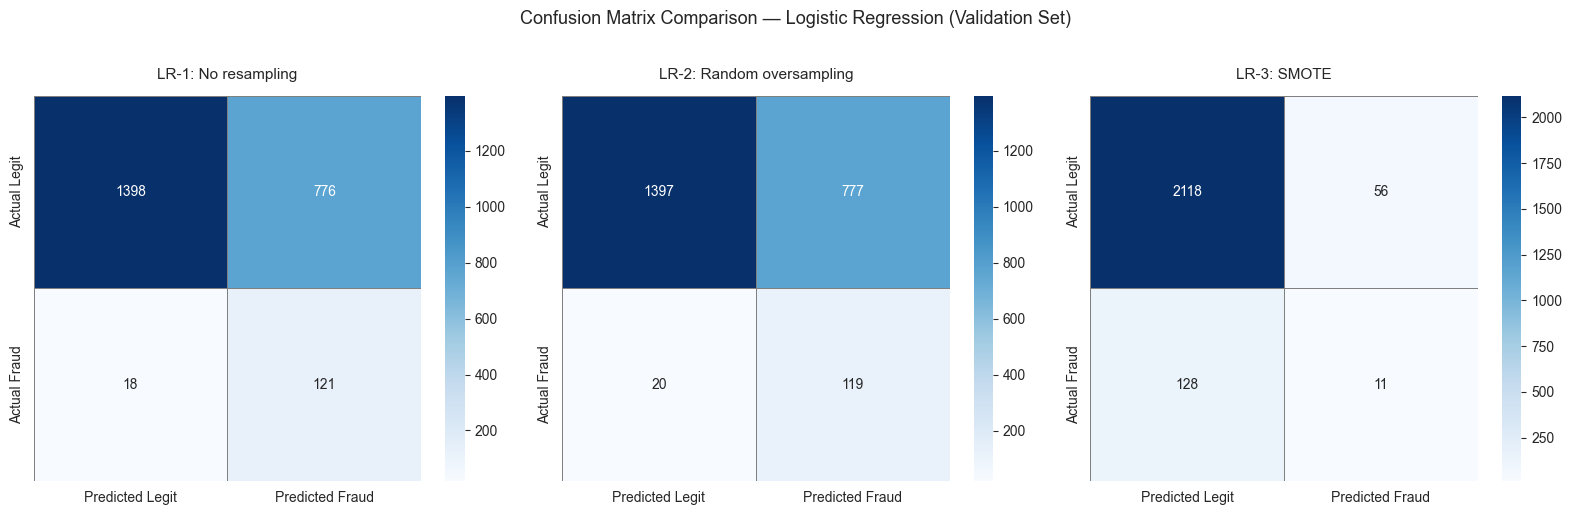

In [26]:
lr1_val_pr_auc   = average_precision_score(y_val, y_val_proba_lr1)
lr1_val_roc_auc  = roc_auc_score(y_val, y_val_proba_lr1)
lr1_val_precision = precision_score(y_val, y_val_pred_lr1, zero_division=0)
lr1_val_recall   = recall_score(y_val, y_val_pred_lr1, zero_division=0)
lr1_val_f1       = f1_score(y_val, y_val_pred_lr1, zero_division=0)
lr1_val_cm       = confusion_matrix(y_val, y_val_pred_lr1)

lr2_val_pr_auc   = average_precision_score(y_val, y_val_proba_lr2)
lr2_val_roc_auc  = roc_auc_score(y_val, y_val_proba_lr2)
lr2_val_precision = precision_score(y_val, y_val_pred_lr2, zero_division=0)
lr2_val_recall   = recall_score(y_val, y_val_pred_lr2, zero_division=0)
lr2_val_f1       = f1_score(y_val, y_val_pred_lr2, zero_division=0)
lr2_val_cm       = confusion_matrix(y_val, y_val_pred_lr2)

lr3_val_pr_auc   = average_precision_score(y_val, y_val_proba_lr3)
lr3_val_roc_auc  = roc_auc_score(y_val, y_val_proba_lr3)
lr3_val_precision = precision_score(y_val, y_val_pred_lr3, zero_division=0)
lr3_val_recall   = recall_score(y_val, y_val_pred_lr3, zero_division=0)
lr3_val_f1       = f1_score(y_val, y_val_pred_lr3, zero_division=0)
lr3_val_cm       = confusion_matrix(y_val, y_val_pred_lr3)

# Summary table
results_lr = pd.DataFrame({
    'Model': ['LR-1 (no resampling)', 'LR-2 (oversampling)', 'LR-3 (SMOTE)'],
    'PR-AUC':    [lr1_val_pr_auc,    lr2_val_pr_auc,    lr3_val_pr_auc],
    'ROC-AUC':   [lr1_val_roc_auc,   lr2_val_roc_auc,   lr3_val_roc_auc],
    'Precision': [lr1_val_precision,  lr2_val_precision,  lr3_val_precision],
    'Recall':    [lr1_val_recall,     lr2_val_recall,     lr3_val_recall],
    'F1':        [lr1_val_f1,         lr2_val_f1,         lr3_val_f1],
}).round(4)

print("\n=== Logistic Regression — Validation Results ===")
print(results_lr.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_lr = [
    (lr1_val_cm, 'LR-1: No resampling'),
    (lr2_val_cm, 'LR-2: Random oversampling'),
    (lr3_val_cm, 'LR-3: SMOTE'),
]

for ax, (cm, title) in zip(axes, models_lr):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix Comparison — Logistic Regression (Validation Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Leakage check

In [27]:
train_idx = set(X_train.index)
val_idx   = set(X_val.index)
test_idx  = set(X_test.index)

print("\nLeakage check")
print(f"Train/Val overlap:  {len(train_idx & val_idx)} samples")
print(f"Train/Test overlap: {len(train_idx & test_idx)} samples")
print(f"Val/Test overlap:   {len(val_idx & test_idx)} samples")
print(f"Total accounted for: {len(train_idx | val_idx | test_idx)} (should be 15420)")


Leakage check
Train/Val overlap:  0 samples
Train/Test overlap: 0 samples
Val/Test overlap:   0 samples
Total accounted for: 15420 (should be 15420)


# Random Forest

In [28]:
def build_rf_model(class_weight=None):
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    return model

In [29]:
# No Resampling
def no_resampling(X_train, y_train):
    """
    Return original training data without modification
    """
    return X_train, y_train

In [30]:
# RF-1: no resampling

X_train_rf1, y_train_rf1 = no_resampling(X_train, y_train)

rf1 = build_rf_model(class_weight="balanced")

rf1.fit(X_train_rf1, y_train_rf1)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [48]:
#Validation predictions
y_val_proba_rf1 = rf1.predict_proba(X_val)[:, 1]
y_val_pred_rf1 = (y_val_proba_rf1 >= 0.5).astype(int)

In [49]:
rf1_val_pr_auc = average_precision_score(y_val, y_val_proba_rf1)
rf1_val_roc_auc = roc_auc_score(y_val, y_val_proba_rf1)
rf1_val_precision = precision_score(y_val, y_val_pred_rf1, zero_division=0)
rf1_val_recall = recall_score(y_val, y_val_pred_rf1, zero_division=0)
rf1_val_f1 = f1_score(y_val, y_val_pred_rf1, zero_division=0)
rf1_val_cm = confusion_matrix(y_val, y_val_pred_rf1)

print("RF-1 Validation")
print(f"PR-AUC:   {rf1_val_pr_auc:.4f}")
print(f"ROC-AUC:  {rf1_val_roc_auc:.4f}")
print(f"Precision:{rf1_val_precision:.4f}")
print(f"Recall:   {rf1_val_recall:.4f}")
print(f"F1-score: {rf1_val_f1:.4f}")
print("Confusion matrix:")
print(rf1_val_cm)

RF-1 Validation
PR-AUC:   0.2438
ROC-AUC:  0.8201
Precision:0.8571
Recall:   0.0432
F1-score: 0.0822
Confusion matrix:
[[2173    1]
 [ 133    6]]


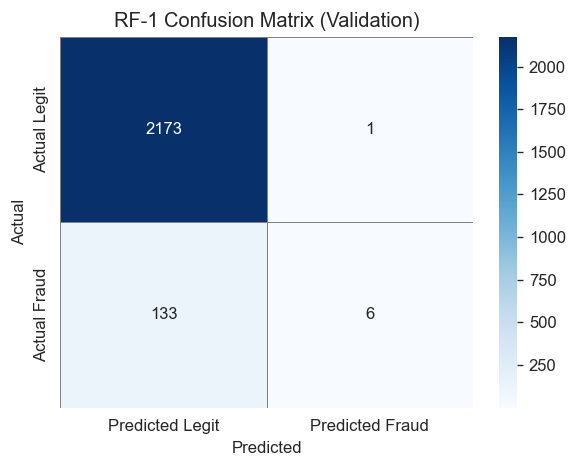

In [56]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    rf1_val_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Legit", "Predicted Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"],
    linewidths=0.5,
    linecolor="gray",
    ax=ax
)

ax.set_title("RF-1 Confusion Matrix (Validation)")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

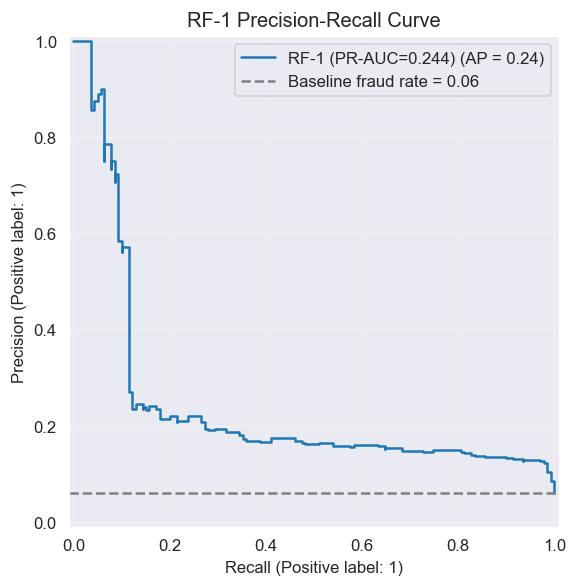

In [57]:
fig, ax = plt.subplots(figsize=(6, 5))

PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_proba_rf1,
    name=f"RF-1 (PR-AUC={rf1_val_pr_auc:.3f})",
    ax=ax
)

fraud_rate = y_val.mean()

ax.axhline(
    fraud_rate,
    color="gray",
    linestyle="--",
    label=f"Baseline fraud rate = {fraud_rate:.2f}"
)

ax.set_title("RF-1 Precision-Recall Curve")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [50]:
# RF-2: Random Oversampling

# Resample training data
X_train_rf2, y_train_rf2 = random_oversampling(X_train, y_train)

# Build model
rf2 = build_rf_model(class_weight=None)

# Fit model
rf2.fit(X_train_rf2, y_train_rf2)

# Validation predictions
y_val_proba_rf2 = rf2.predict_proba(X_val)[:, 1]
y_val_pred_rf2 = (y_val_proba_rf2 >= 0.5).astype(int)

In [51]:
# Validation metrics
rf2_val_pr_auc = average_precision_score(y_val, y_val_proba_rf2)
rf2_val_roc_auc = roc_auc_score(y_val, y_val_proba_rf2)
rf2_val_precision = precision_score(y_val, y_val_pred_rf2, zero_division=0)
rf2_val_recall = recall_score(y_val, y_val_pred_rf2, zero_division=0)
rf2_val_f1 = f1_score(y_val, y_val_pred_rf2, zero_division=0)
rf2_val_cm = confusion_matrix(y_val, y_val_pred_rf2)

In [52]:
print("RF-2 Validation")
print(f"PR-AUC:   {rf2_val_pr_auc:.4f}")
print(f"ROC-AUC:  {rf2_val_roc_auc:.4f}")
print(f"Precision:{rf2_val_precision:.4f}")
print(f"Recall:   {rf2_val_recall:.4f}")
print(f"F1-score: {rf2_val_f1:.4f}")
print("Confusion matrix:")
print(rf2_val_cm)

RF-2 Validation
PR-AUC:   0.2363
ROC-AUC:  0.8186
Precision:0.6923
Recall:   0.0647
F1-score: 0.1184
Confusion matrix:
[[2170    4]
 [ 130    9]]


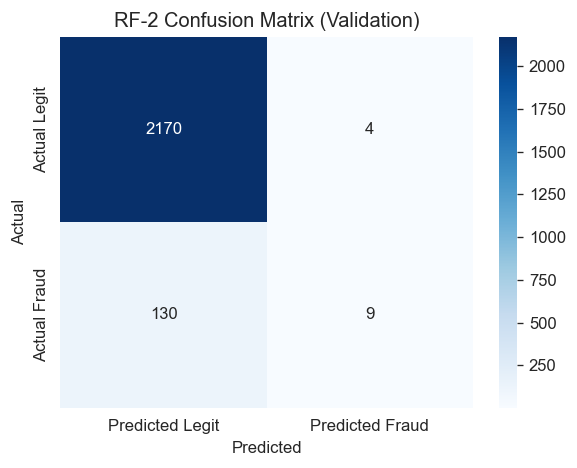

In [53]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    rf2_val_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Legit", "Predicted Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"],
    ax=ax
)
ax.set_title("RF-2 Confusion Matrix (Validation)")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

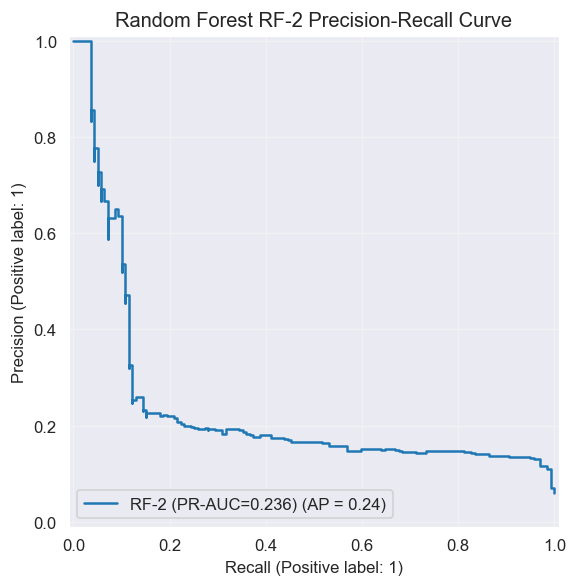

In [55]:

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_proba_rf2,
    name=f"RF-2 (PR-AUC={rf2_val_pr_auc:.3f})",
    ax=ax
)
ax.set_title("Random Forest RF-2 Precision-Recall Curve")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# Resample training data
X_train_rf3, y_train_rf3 = smote_resampling(X_train, y_train)

# Build model
rf3 = build_rf_model(class_weight=None)

# Fit model
rf3.fit(X_train_rf3, y_train_rf3)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [59]:
# Validation predictions
y_val_proba_rf3 = rf3.predict_proba(X_val)[:, 1]
y_val_pred_rf3 = (y_val_proba_rf3 >= 0.5).astype(int)

# Validation metrics
rf3_val_pr_auc = average_precision_score(y_val, y_val_proba_rf3)
rf3_val_roc_auc = roc_auc_score(y_val, y_val_proba_rf3)
rf3_val_precision = precision_score(y_val, y_val_pred_rf3, zero_division=0)
rf3_val_recall = recall_score(y_val, y_val_pred_rf3, zero_division=0)
rf3_val_f1 = f1_score(y_val, y_val_pred_rf3, zero_division=0)
rf3_val_cm = confusion_matrix(y_val, y_val_pred_rf3)

print("RF-3 Validation")
print(f"PR-AUC:   {rf3_val_pr_auc:.4f}")
print(f"ROC-AUC:  {rf3_val_roc_auc:.4f}")
print(f"Precision:{rf3_val_precision:.4f}")
print(f"Recall:   {rf3_val_recall:.4f}")
print(f"F1-score: {rf3_val_f1:.4f}")
print("Confusion matrix:")
print(rf3_val_cm)

RF-3 Validation
PR-AUC:   0.2267
ROC-AUC:  0.8161
Precision:0.6250
Recall:   0.0360
F1-score: 0.0680
Confusion matrix:
[[2171    3]
 [ 134    5]]


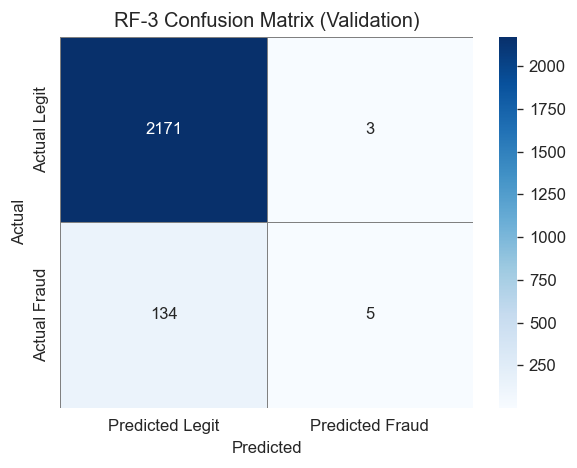

In [60]:
#RF-3 Confusion Matrix (Validation)
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    rf3_val_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Legit", "Predicted Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"],
    linewidths=0.5,
    linecolor="gray",
    ax=ax
)

ax.set_title("RF-3 Confusion Matrix (Validation)")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

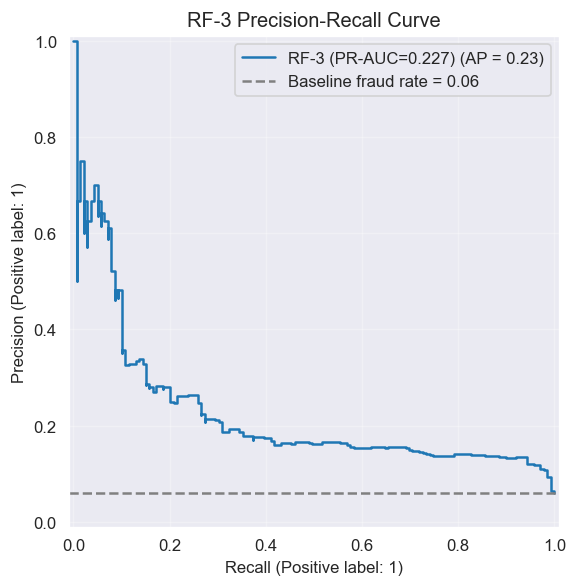

In [61]:
fig, ax = plt.subplots(figsize=(6, 5))

PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_proba_rf3,
    name=f"RF-3 (PR-AUC={rf3_val_pr_auc:.3f})",
    ax=ax
)

fraud_rate = y_val.mean()

ax.axhline(
    fraud_rate,
    color="gray",
    linestyle="--",
    label=f"Baseline fraud rate = {fraud_rate:.2f}"
)

ax.set_title("RF-3 Precision-Recall Curve")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

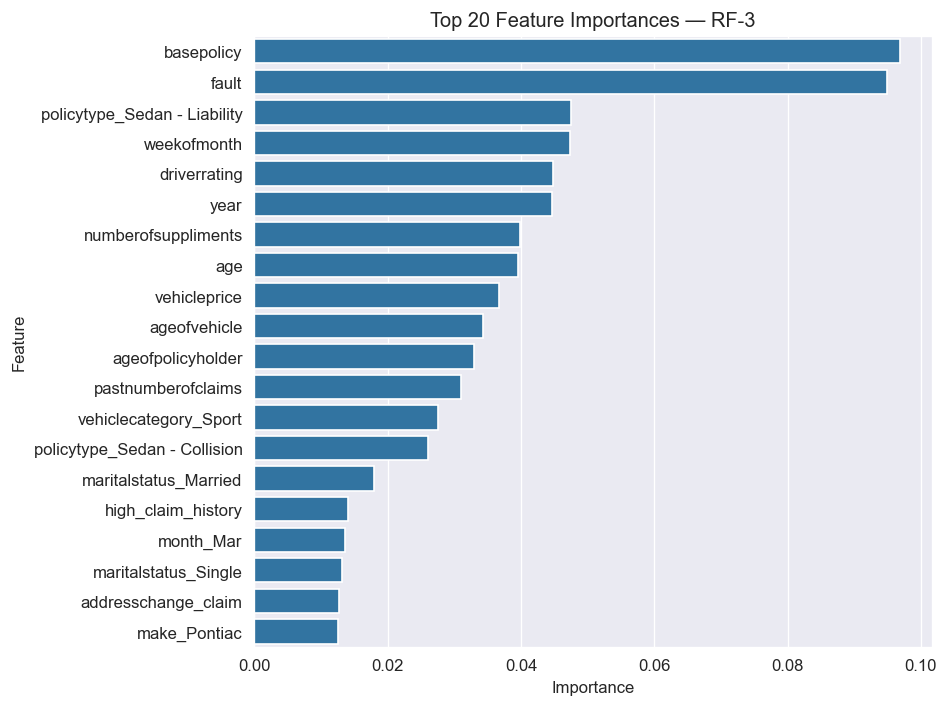

In [62]:
rf3_importances = pd.Series(rf3.feature_importances_, index=X_train.columns)
top20_rf3 = rf3_importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    x=top20_rf3.values,
    y=top20_rf3.index,
    ax=ax
)

ax.set_title("Top 20 Feature Importances — RF-3")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [63]:
# Random Forest Comparison Table

results_rf = pd.DataFrame({
    "Model": [
        "RF-1 (no resampling)",
        "RF-2 (random oversampling)",
        "RF-3 (SMOTE)"
    ],

    "PR-AUC": [
        rf1_val_pr_auc,
        rf2_val_pr_auc,
        rf3_val_pr_auc
    ],

    "ROC-AUC": [
        rf1_val_roc_auc,
        rf2_val_roc_auc,
        rf3_val_roc_auc
    ],

    "Precision": [
        rf1_val_precision,
        rf2_val_precision,
        rf3_val_precision
    ],

    "Recall": [
        rf1_val_recall,
        rf2_val_recall,
        rf3_val_recall
    ],

    "F1": [
        rf1_val_f1,
        rf2_val_f1,
        rf3_val_f1
    ]
}).round(4)

print("=== Random Forest Validation Results ===")
print(results_rf.to_string(index=False))

=== Random Forest Validation Results ===
                     Model  PR-AUC  ROC-AUC  Precision  Recall     F1
      RF-1 (no resampling)  0.2438   0.8201     0.8571  0.0432 0.0822
RF-2 (random oversampling)  0.2363   0.8186     0.6923  0.0647 0.1184
              RF-3 (SMOTE)  0.2267   0.8161     0.6250  0.0360 0.0680


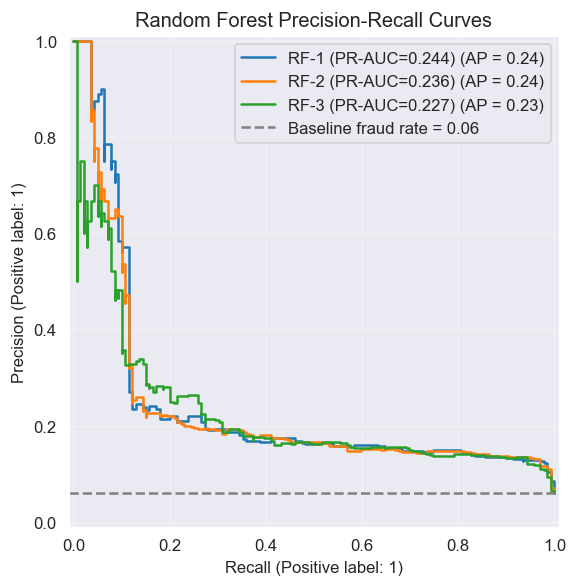

In [64]:
fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_proba_rf1,
    name=f"RF-1 (PR-AUC={rf1_val_pr_auc:.3f})",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_proba_rf2,
    name=f"RF-2 (PR-AUC={rf2_val_pr_auc:.3f})",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_proba_rf3,
    name=f"RF-3 (PR-AUC={rf3_val_pr_auc:.3f})",
    ax=ax
)

fraud_rate = y_val.mean()

ax.axhline(
    fraud_rate,
    color="gray",
    linestyle="--",
    label=f"Baseline fraud rate = {fraud_rate:.2f}"
)

ax.set_title("Random Forest Precision-Recall Curves")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Random Forest Hyperparameter Tuning - RF-1

In [66]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Parameter search space
rf_param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Base RF model
base_rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Randomized search
rf_random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit search
rf_random_search.fit(X_train, y_train)

# Results
rf_best_params = rf_random_search.best_params_
rf_best_score = rf_random_search.best_score_

print("=== RF-1 Coarse Search Results ===")
print(f"Best CV PR-AUC: {rf_best_score:.4f}")
print("Best Parameters:")
print(rf_best_params)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


Python(42116) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(42117) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(42118) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(42119) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(42120) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(42121) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(42122) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(42123) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


=== RF-1 Coarse Search Results ===
Best CV PR-AUC: 0.1907
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}


In [67]:
# Build tuned RF model

rf1_tuned = RandomForestClassifier(
    n_estimators=rf_best_params["n_estimators"],
    max_depth=rf_best_params["max_depth"],
    min_samples_split=rf_best_params["min_samples_split"],
    min_samples_leaf=rf_best_params["min_samples_leaf"],
    max_features=rf_best_params["max_features"],
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train
rf1_tuned.fit(X_train, y_train)

# Validation probabilities
y_val_proba_rf1_tuned = rf1_tuned.predict_proba(X_val)[:, 1]

# Validation predictions
y_val_pred_rf1_tuned = (
    y_val_proba_rf1_tuned >= 0.5
).astype(int)

# Metrics
rf1_tuned_val_pr_auc = average_precision_score(
    y_val,
    y_val_proba_rf1_tuned
)

rf1_tuned_val_roc_auc = roc_auc_score(
    y_val,
    y_val_proba_rf1_tuned
)

rf1_tuned_val_precision = precision_score(
    y_val,
    y_val_pred_rf1_tuned,
    zero_division=0
)

rf1_tuned_val_recall = recall_score(
    y_val,
    y_val_pred_rf1_tuned,
    zero_division=0
)

rf1_tuned_val_f1 = f1_score(
    y_val,
    y_val_pred_rf1_tuned,
    zero_division=0
)

print("=== RF-1 Tuned Validation Results ===")
print(f"PR-AUC:   {rf1_tuned_val_pr_auc:.4f}")
print(f"ROC-AUC:  {rf1_tuned_val_roc_auc:.4f}")
print(f"Precision:{rf1_tuned_val_precision:.4f}")
print(f"Recall:   {rf1_tuned_val_recall:.4f}")
print(f"F1-score: {rf1_tuned_val_f1:.4f}")

=== RF-1 Tuned Validation Results ===
PR-AUC:   0.2349
ROC-AUC:  0.8239
Precision:0.5556
Recall:   0.0719
F1-score: 0.1274


In [68]:
thresholds = np.arange(0.05, 0.55, 0.05)

rf_thresh_rows = []

for t in thresholds:

    preds = (
        y_val_proba_rf1_tuned >= t
    ).astype(int)

    rf_thresh_rows.append({
        "threshold": round(t, 2),

        "precision": round(
            precision_score(
                y_val,
                preds,
                zero_division=0
            ),
            3
        ),

        "recall": round(
            recall_score(
                y_val,
                preds,
                zero_division=0
            ),
            3
        ),

        "f1": round(
            f1_score(
                y_val,
                preds,
                zero_division=0
            ),
            3
        )
    })

rf_thresh_df = pd.DataFrame(rf_thresh_rows)

best_rf_idx = rf_thresh_df["f1"].idxmax()

best_rf_threshold = rf_thresh_df.loc[
    best_rf_idx,
    "threshold"
]

print("=== RF-1 Threshold Sweep ===")
print(rf_thresh_df.to_string(index=False))

print(f"\nBest threshold: {best_rf_threshold:.2f}")

=== RF-1 Threshold Sweep ===
 threshold  precision  recall    f1
      0.05      0.108   0.993 0.195
      0.10      0.130   0.971 0.229
      0.15      0.143   0.863 0.245
      0.20      0.154   0.633 0.247
      0.25      0.177   0.446 0.253
      0.30      0.204   0.295 0.241
      0.35      0.231   0.173 0.198
      0.40      0.340   0.129 0.188
      0.45      0.517   0.108 0.179
      0.50      0.556   0.072 0.127

Best threshold: 0.25


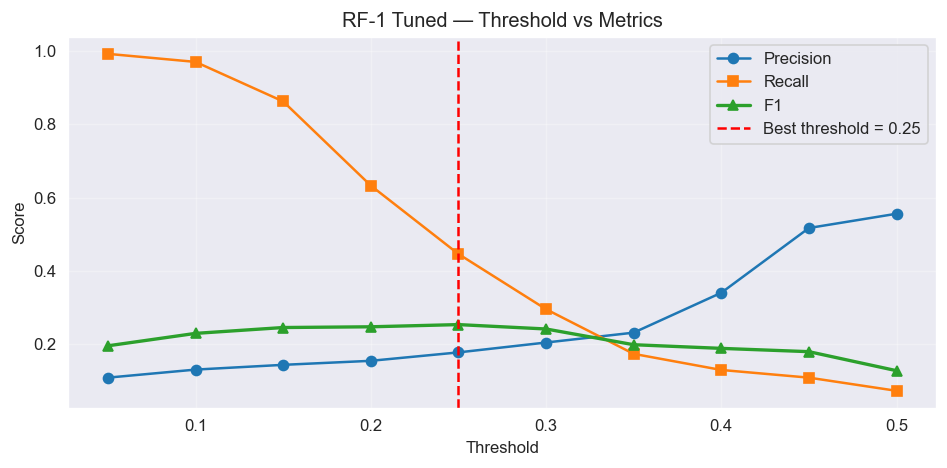

In [69]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    rf_thresh_df["threshold"],
    rf_thresh_df["precision"],
    marker="o",
    label="Precision"
)

ax.plot(
    rf_thresh_df["threshold"],
    rf_thresh_df["recall"],
    marker="s",
    label="Recall"
)

ax.plot(
    rf_thresh_df["threshold"],
    rf_thresh_df["f1"],
    marker="^",
    linewidth=2,
    label="F1"
)

ax.axvline(
    best_rf_threshold,
    color="red",
    linestyle="--",
    label=f"Best threshold = {best_rf_threshold:.2f}"
)

ax.set_title(
    "RF-1 Tuned — Threshold vs Metrics"
)

ax.set_xlabel("Threshold")
ax.set_ylabel("Score")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# XGB Boost

In [31]:
def build_xgb_model(scale_pos_weight=1.0):
    # Core XGBoost model
    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )
    
    return model

###  XGB-1: no resampling

In [32]:
# XGB-1: no resampling

# Keep original training data
X_train_nr, y_train_nr = no_resampling(X_train, y_train)

# Compute imbalance ratio
neg = (y_train_nr == 0).sum()
pos = (y_train_nr == 1).sum()
scale_pos_weight = neg / pos

# Build model
xgb_xgb1 = build_xgb_model(scale_pos_weight=scale_pos_weight)

# Fit model
xgb_xgb1.fit(X_train_nr, y_train_nr)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [33]:
# XGB-1: predictions and metrics

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# Validation predictions
y_val_proba_xgb1 = xgb_xgb1.predict_proba(X_val)[:, 1]
y_val_pred_xgb1 = (y_val_proba_xgb1 >= 0.5).astype(int)

# Validation metrics
xgb1_val_pr_auc = average_precision_score(y_val, y_val_proba_xgb1)
xgb1_val_roc_auc = roc_auc_score(y_val, y_val_proba_xgb1)
xgb1_val_precision = precision_score(y_val, y_val_pred_xgb1, zero_division=0)
xgb1_val_recall = recall_score(y_val, y_val_pred_xgb1, zero_division=0)
xgb1_val_f1 = f1_score(y_val, y_val_pred_xgb1, zero_division=0)
xgb1_val_cm = confusion_matrix(y_val, y_val_pred_xgb1)

print("XGB-1 Validation")
print(f"PR-AUC:   {xgb1_val_pr_auc:.4f}")
print(f"ROC-AUC:  {xgb1_val_roc_auc:.4f}")
print(f"Precision:{xgb1_val_precision:.4f}")
print(f"Recall:   {xgb1_val_recall:.4f}")
print(f"F1-score: {xgb1_val_f1:.4f}")
print("Confusion matrix:")
print(xgb1_val_cm)

# Test predictions
y_test_proba_xgb1 = xgb_xgb1.predict_proba(X_test)[:, 1]
y_test_pred_xgb1 = (y_test_proba_xgb1 >= 0.5).astype(int)

# Test metrics
xgb1_test_pr_auc = average_precision_score(y_test, y_test_proba_xgb1)
xgb1_test_roc_auc = roc_auc_score(y_test, y_test_proba_xgb1)
xgb1_test_precision = precision_score(y_test, y_test_pred_xgb1, zero_division=0)
xgb1_test_recall = recall_score(y_test, y_test_pred_xgb1, zero_division=0)
xgb1_test_f1 = f1_score(y_test, y_test_pred_xgb1, zero_division=0)
xgb1_test_cm = confusion_matrix(y_test, y_test_pred_xgb1)

print("\nXGB-1 Test")
print(f"PR-AUC:   {xgb1_test_pr_auc:.4f}")
print(f"ROC-AUC:  {xgb1_test_roc_auc:.4f}")
print(f"Precision:{xgb1_test_precision:.4f}")
print(f"Recall:   {xgb1_test_recall:.4f}")
print(f"F1-score: {xgb1_test_f1:.4f}")
print("Confusion matrix:")
print(xgb1_test_cm)

XGB-1 Validation
PR-AUC:   0.2785
ROC-AUC:  0.8513
Precision:0.1720
Recall:   0.8058
F1-score: 0.2835
Confusion matrix:
[[1635  539]
 [  27  112]]

XGB-1 Test
PR-AUC:   0.2304
ROC-AUC:  0.8592
Precision:0.1751
Recall:   0.8261
F1-score: 0.2890
Confusion matrix:
[[1638  537]
 [  24  114]]


### XGB-2: Random Oversampling

In [34]:
# XGB-2: random oversampling

# Resample training data
X_train_ros, y_train_ros = random_oversampling(X_train, y_train)

# Build model
xgb_xgb2 = build_xgb_model(scale_pos_weight=1.0)

# Fit model
xgb_xgb2.fit(X_train_ros, y_train_ros)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [35]:
# XGB-2: predictions and metrics

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# Validation predictions
y_val_proba_xgb2 = xgb_xgb2.predict_proba(X_val)[:, 1]
y_val_pred_xgb2 = (y_val_proba_xgb2 >= 0.5).astype(int)

# Validation metrics
xgb2_val_pr_auc = average_precision_score(y_val, y_val_proba_xgb2)
xgb2_val_roc_auc = roc_auc_score(y_val, y_val_proba_xgb2)
xgb2_val_precision = precision_score(y_val, y_val_pred_xgb2, zero_division=0)
xgb2_val_recall = recall_score(y_val, y_val_pred_xgb2, zero_division=0)
xgb2_val_f1 = f1_score(y_val, y_val_pred_xgb2, zero_division=0)
xgb2_val_cm = confusion_matrix(y_val, y_val_pred_xgb2)

print("XGB-2 Validation")
print(f"PR-AUC:   {xgb2_val_pr_auc:.4f}")
print(f"ROC-AUC:  {xgb2_val_roc_auc:.4f}")
print(f"Precision:{xgb2_val_precision:.4f}")
print(f"Recall:   {xgb2_val_recall:.4f}")
print(f"F1-score: {xgb2_val_f1:.4f}")
print("Confusion matrix:")
print(xgb2_val_cm)

# Test predictions
y_test_proba_xgb2 = xgb_xgb2.predict_proba(X_test)[:, 1]
y_test_pred_xgb2 = (y_test_proba_xgb2 >= 0.5).astype(int)

# Test metrics
xgb2_test_pr_auc = average_precision_score(y_test, y_test_proba_xgb2)
xgb2_test_roc_auc = roc_auc_score(y_test, y_test_proba_xgb2)
xgb2_test_precision = precision_score(y_test, y_test_pred_xgb2, zero_division=0)
xgb2_test_recall = recall_score(y_test, y_test_pred_xgb2, zero_division=0)
xgb2_test_f1 = f1_score(y_test, y_test_pred_xgb2, zero_division=0)
xgb2_test_cm = confusion_matrix(y_test, y_test_pred_xgb2)

print("\nXGB-2 Test")
print(f"PR-AUC:   {xgb2_test_pr_auc:.4f}")
print(f"ROC-AUC:  {xgb2_test_roc_auc:.4f}")
print(f"Precision:{xgb2_test_precision:.4f}")
print(f"Recall:   {xgb2_test_recall:.4f}")
print(f"F1-score: {xgb2_test_f1:.4f}")
print("Confusion matrix:")
print(xgb2_test_cm)

XGB-2 Validation
PR-AUC:   0.2894
ROC-AUC:  0.8570
Precision:0.1662
Recall:   0.8058
F1-score: 0.2755
Confusion matrix:
[[1612  562]
 [  27  112]]

XGB-2 Test
PR-AUC:   0.2590
ROC-AUC:  0.8679
Precision:0.1705
Recall:   0.8551
F1-score: 0.2843
Confusion matrix:
[[1601  574]
 [  20  118]]


In [36]:
# XGB-3: SMOTE

# Resample training data with SMOTE
X_train_smote, y_train_smote = smote_resampling(X_train, y_train)

# Build model
xgb_xgb3 = build_xgb_model(scale_pos_weight=1.0)

# Fit model
xgb_xgb3.fit(X_train_smote, y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [37]:
# XGB-3: predictions and metrics

# Validation predictions
y_val_proba_xgb3 = xgb_xgb3.predict_proba(X_val)[:, 1]
y_val_pred_xgb3 = (y_val_proba_xgb3 >= 0.5).astype(int)

# Validation metrics
xgb3_val_pr_auc = average_precision_score(y_val, y_val_proba_xgb3)
xgb3_val_roc_auc = roc_auc_score(y_val, y_val_proba_xgb3)
xgb3_val_precision = precision_score(y_val, y_val_pred_xgb3, zero_division=0)
xgb3_val_recall = recall_score(y_val, y_val_pred_xgb3, zero_division=0)
xgb3_val_f1 = f1_score(y_val, y_val_pred_xgb3, zero_division=0)
xgb3_val_cm = confusion_matrix(y_val, y_val_pred_xgb3)

print("XGB-3 Validation")
print(f"PR-AUC:   {xgb3_val_pr_auc:.4f}")
print(f"ROC-AUC:  {xgb3_val_roc_auc:.4f}")
print(f"Precision:{xgb3_val_precision:.4f}")
print(f"Recall:   {xgb3_val_recall:.4f}")
print(f"F1-score: {xgb3_val_f1:.4f}")
print("Confusion matrix:")
print(xgb3_val_cm)

# Test predictions
y_test_proba_xgb3 = xgb_xgb3.predict_proba(X_test)[:, 1]
y_test_pred_xgb3 = (y_test_proba_xgb3 >= 0.5).astype(int)

# Test metrics
xgb3_test_pr_auc = average_precision_score(y_test, y_test_proba_xgb3)
xgb3_test_roc_auc = roc_auc_score(y_test, y_test_proba_xgb3)
xgb3_test_precision = precision_score(y_test, y_test_pred_xgb3, zero_division=0)
xgb3_test_recall = recall_score(y_test, y_test_pred_xgb3, zero_division=0)
xgb3_test_f1 = f1_score(y_test, y_test_pred_xgb3, zero_division=0)
xgb3_test_cm = confusion_matrix(y_test, y_test_pred_xgb3)

print("\nXGB-3 Test")
print(f"PR-AUC:   {xgb3_test_pr_auc:.4f}")
print(f"ROC-AUC:  {xgb3_test_roc_auc:.4f}")
print(f"Precision:{xgb3_test_precision:.4f}")
print(f"Recall:   {xgb3_test_recall:.4f}")
print(f"F1-score: {xgb3_test_f1:.4f}")
print("Confusion matrix:")
print(xgb3_test_cm)

XGB-3 Validation
PR-AUC:   0.2690
ROC-AUC:  0.8482
Precision:0.5714
Recall:   0.0863
F1-score: 0.1500
Confusion matrix:
[[2165    9]
 [ 127   12]]

XGB-3 Test
PR-AUC:   0.2148
ROC-AUC:  0.8608
Precision:0.1765
Recall:   0.0217
F1-score: 0.0387
Confusion matrix:
[[2161   14]
 [ 135    3]]


## XGBoost Hyperparameter Tuning — Coarse-to-Fine Search
 
Following the course methodology (Lecture 12), we apply a **coarse-to-fine** strategy:
 
1. **Coarse stage** — `RandomizedSearchCV` with 15 random combinations across a broad
   parameter space, evaluated via 3-fold stratified cross-validation on the training set.
   This identifies the region of high potential in parameter space.
 
2. **Fine stage** — A targeted manual grid search over the three most impactful parameters
   (`n_estimators`, `max_depth`, `learning_rate`) around the coarse best values, with
   all other parameters fixed at coarse best.
 
3. **Threshold tuning** — The default threshold of 0.5 is arbitrary. We sweep thresholds
   on the **validation set only** to find the best balance of precision and recall.
 
4. **Test evaluation** — The test set is touched **once**, using the best model and
   best threshold chosen on validation.
 
Key constraint: validation and test sets are never used during training or tuning.
Scoring metric: `average_precision` (= PR-AUC), consistent with our main evaluation metric.
"""

In [38]:
### CELL 2 — Imports for tuning ###
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
from sklearn import set_config
set_config(display='text')
 
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
 

"""
### Stage 1: Coarse Random Search — XGB-1 (no resampling)
 
We sample 15 random combinations from a broad distribution.
Scoring is `average_precision` (PR-AUC) via 3-fold CV on training data.
"""

In [39]:
import numpy as np
 
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Class imbalance ratio: {scale_pos_weight:.1f}x  (used as scale_pos_weight)")
 
coarse_param_dist = {
    "n_estimators":     [200, 400],
    "learning_rate":    [0.03, 0.05, 0.08],
    "max_depth":        [3, 4, 5],
    "subsample":        [0.7, 0.9],
    "colsample_bytree": [0.7, 1.0],
    "reg_lambda":       [0.5, 2.0],
    "min_child_weight": [1, 5],
}
 
base_xgb1 = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)
 
coarse_search_xgb1 = RandomizedSearchCV(
    base_xgb1,
    coarse_param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)
coarse_search_xgb1.fit(X_train, y_train)
 
coarse_best_xgb1 = coarse_search_xgb1.best_params_
print(f"\nCoarse best CV PR-AUC: {coarse_search_xgb1.best_score_:.4f}")
print(f"Coarse best params:    {coarse_best_xgb1}")

Class imbalance ratio: 15.7x  (used as scale_pos_weight)

Coarse best CV PR-AUC: 0.2337
Coarse best params:    {'subsample': 0.9, 'reg_lambda': 0.5, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


"""
### Stage 2: Fine Manual Grid — XGB-1
 
We fix the coarse best values for `subsample`, `colsample_bytree`, `reg_lambda`,
and `min_child_weight`, then do a fine grid over the three highest-impact parameters:
`n_estimators`, `max_depth`, and `learning_rate`.
 
This is the "coarse-to-fine" approach from Lecture 12: random search to find the
region, grid search to exploit it precisely.
"""

fine_results_xgb1 = []
 
for n_est in [350, 400, 500]:
    for depth in [4, 5, 6]:
        for lr in [0.02, 0.03, 0.05]:
            m = xgb.XGBClassifier(
                objective="binary:logistic",
                eval_metric="aucpr",
                n_estimators=n_est,
                learning_rate=lr,
                max_depth=depth,
                subsample=0.9,
                colsample_bytree=1.0,
                reg_lambda=0.5,
                min_child_weight=1,
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=-1,
                tree_method="hist",
            )
            m.fit(X_train, y_train)
            p = m.predict_proba(X_val)[:, 1]
            score = average_precision_score(y_val, p)
            fine_results_xgb1.append({
                "n_estimators": n_est,
                "max_depth": depth,
                "learning_rate": lr,
                "val_pr_auc": round(score, 4),
            })
 
fine_df_xgb1 = pd.DataFrame(fine_results_xgb1).sort_values("val_pr_auc", ascending=False)
print("Fine grid results (top 10):")
print(fine_df_xgb1.head(10).to_string(index=False))
 
best_fine_xgb1 = fine_df_xgb1.iloc[0]
print(f"\nBest fine params: n_estimators={int(best_fine_xgb1['n_estimators'])}, "
      f"max_depth={int(best_fine_xgb1['max_depth'])}, learning_rate={best_fine_xgb1['learning_rate']}")
print(f"Val PR-AUC: {best_fine_xgb1['val_pr_auc']:.4f}")

In [40]:
xgb1_tuned = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=350,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=1.0,
    reg_lambda=0.5,
    min_child_weight=1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)
xgb1_tuned.fit(X_train, y_train)
y_val_proba_xgb1_tuned = xgb1_tuned.predict_proba(X_val)[:, 1]
 
xgb1_tuned_val_prauc  = average_precision_score(y_val, y_val_proba_xgb1_tuned)
xgb1_tuned_val_rocauc = roc_auc_score(y_val, y_val_proba_xgb1_tuned)
print(f"XGB-1 Tuned | Val PR-AUC: {xgb1_tuned_val_prauc:.4f}  Val ROC-AUC: {xgb1_tuned_val_rocauc:.4f}")

XGB-1 Tuned | Val PR-AUC: 0.2892  Val ROC-AUC: 0.8604


"""
### Stage 3: Threshold Tuning — XGB-1
 
The default threshold of 0.5 is arbitrary (Lecture 12). We sweep thresholds from 0.10
to 0.80 on the **validation set** and pick the one that maximises F1. This balances
the business cost of missing fraud (false negatives) against annoying legitimate
customers (false positives).
 
Important: the threshold is selected on validation data. The test set is not touched here.
"""

XGB-1 Threshold sweep (validation):
 threshold  precision  recall    f1
      0.10      0.125   0.964 0.221
      0.15      0.137   0.950 0.240
      0.20      0.146   0.921 0.252
      0.25      0.155   0.899 0.265
      0.30      0.164   0.863 0.275
      0.35      0.175   0.842 0.290
      0.40      0.185   0.806 0.301
      0.45      0.196   0.755 0.312
      0.50      0.213   0.691 0.325
      0.55      0.228   0.597 0.330
      0.60      0.227   0.489 0.310
      0.65      0.222   0.360 0.275
      0.70      0.240   0.259 0.249
      0.75      0.281   0.194 0.230
      0.80      0.328   0.137 0.193

=> Best threshold: 0.55  F1=0.330  Precision=0.228  Recall=0.597


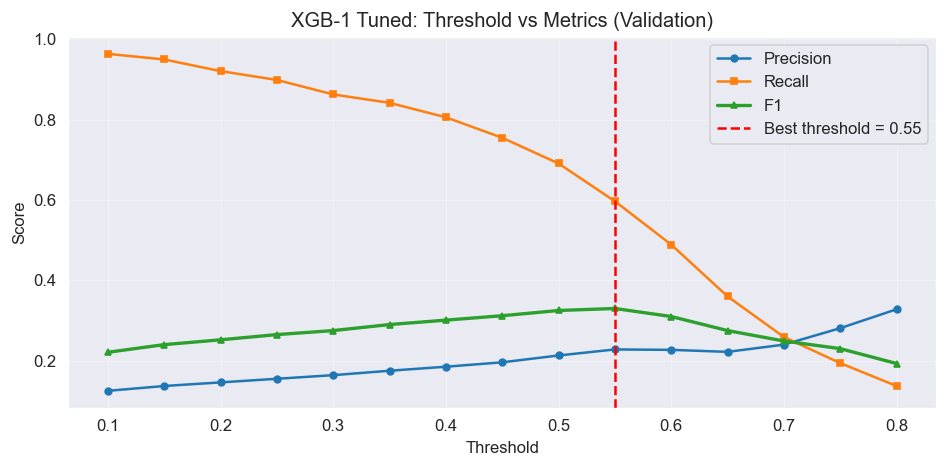

In [41]:
thresholds = np.arange(0.10, 0.85, 0.05)
thresh_rows_xgb1 = []
 
for t in thresholds:
    preds = (y_val_proba_xgb1_tuned >= t).astype(int)
    thresh_rows_xgb1.append({
        "threshold": round(t, 2),
        "precision": round(precision_score(y_val, preds, zero_division=0), 3),
        "recall":    round(recall_score(y_val, preds, zero_division=0), 3),
        "f1":        round(f1_score(y_val, preds, zero_division=0), 3),
    })
 
thresh_df_xgb1 = pd.DataFrame(thresh_rows_xgb1)
best_idx_xgb1  = thresh_df_xgb1["f1"].idxmax()
best_t_xgb1    = thresh_df_xgb1.loc[best_idx_xgb1, "threshold"]
print("XGB-1 Threshold sweep (validation):")
print(thresh_df_xgb1.to_string(index=False))
print(f"\n=> Best threshold: {best_t_xgb1:.2f}  "
      f"F1={thresh_df_xgb1.loc[best_idx_xgb1,'f1']:.3f}  "
      f"Precision={thresh_df_xgb1.loc[best_idx_xgb1,'precision']:.3f}  "
      f"Recall={thresh_df_xgb1.loc[best_idx_xgb1,'recall']:.3f}")
 
# Plot threshold vs precision/recall/F1
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresh_df_xgb1["threshold"], thresh_df_xgb1["precision"], label="Precision", marker="o", ms=4)
ax.plot(thresh_df_xgb1["threshold"], thresh_df_xgb1["recall"],    label="Recall",    marker="s", ms=4)
ax.plot(thresh_df_xgb1["threshold"], thresh_df_xgb1["f1"],        label="F1",        marker="^", ms=4, lw=2)
ax.axvline(best_t_xgb1, color="red", linestyle="--", label=f"Best threshold = {best_t_xgb1:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_title("XGB-1 Tuned: Threshold vs Metrics (Validation)")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
 

"""
### Coarse-to-Fine Tuning — XGB-2 (Random Oversampling)
 
We repeat the same two-stage process for XGB-2.
"""


In [42]:
X_train_ros, y_train_ros = random_oversampling(X_train, y_train)
 
coarse_search_xgb2 = RandomizedSearchCV(
    xgb.XGBClassifier(
        objective="binary:logistic", eval_metric="aucpr",
        scale_pos_weight=1.0, random_state=42, n_jobs=-1, tree_method="hist",
    ),
    coarse_param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)
coarse_search_xgb2.fit(X_train_ros, y_train_ros)
coarse_best_xgb2 = coarse_search_xgb2.best_params_
print(f"XGB-2 Coarse best CV PR-AUC: {coarse_search_xgb2.best_score_:.4f}")
print(f"XGB-2 Coarse best params:    {coarse_best_xgb2}")
 
# Fine grid XGB-2
fine_results_xgb2 = []
for n_est in [350, 400, 500]:
    for depth in [4, 5, 6]:
        for lr in [0.02, 0.03, 0.05]:
            m = xgb.XGBClassifier(
                objective="binary:logistic", eval_metric="aucpr",
                n_estimators=n_est, learning_rate=lr, max_depth=depth,
                subsample=0.9, colsample_bytree=1.0, reg_lambda=0.5,
                min_child_weight=1, scale_pos_weight=1.0,
                random_state=42, n_jobs=-1, tree_method="hist",
            )
            m.fit(X_train_ros, y_train_ros)
            p = m.predict_proba(X_val)[:, 1]
            score = average_precision_score(y_val, p)
            fine_results_xgb2.append({"n_estimators": n_est, "max_depth": depth,
                                       "learning_rate": lr, "val_pr_auc": round(score, 4)})
 
fine_df_xgb2 = pd.DataFrame(fine_results_xgb2).sort_values("val_pr_auc", ascending=False)
print("\nXGB-2 Fine grid results (top 10):")
print(fine_df_xgb2.head(10).to_string(index=False))

XGB-2 Coarse best CV PR-AUC: 0.9789
XGB-2 Coarse best params:    {'subsample': 0.9, 'reg_lambda': 2.0, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.08, 'colsample_bytree': 1.0}

XGB-2 Fine grid results (top 10):
 n_estimators  max_depth  learning_rate  val_pr_auc
          400          5           0.03      0.2923
          400          6           0.03      0.2920
          500          5           0.03      0.2914
          350          6           0.03      0.2911
          350          5           0.03      0.2910
          350          5           0.05      0.2900
          400          4           0.03      0.2883
          500          5           0.02      0.2878
          400          5           0.05      0.2874
          400          5           0.02      0.2873


In [43]:
xgb2_tuned = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=1.0,
    reg_lambda=0.5,
    min_child_weight=1,
    scale_pos_weight=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)
xgb2_tuned.fit(X_train_ros, y_train_ros)
y_val_proba_xgb2_tuned = xgb2_tuned.predict_proba(X_val)[:, 1]
 
xgb2_tuned_val_prauc  = average_precision_score(y_val, y_val_proba_xgb2_tuned)
xgb2_tuned_val_rocauc = roc_auc_score(y_val, y_val_proba_xgb2_tuned)
print(f"XGB-2 Tuned | Val PR-AUC: {xgb2_tuned_val_prauc:.4f}  Val ROC-AUC: {xgb2_tuned_val_rocauc:.4f}")

XGB-2 Tuned | Val PR-AUC: 0.2923  Val ROC-AUC: 0.8603


thresh_rows_xgb2 = []
for t in thresholds:
    preds = (y_val_proba_xgb2_tuned >= t).astype(int)
    thresh_rows_xgb2.append({
        "threshold": round(t, 2),
        "precision": round(precision_score(y_val, preds, zero_division=0), 3),
        "recall":    round(recall_score(y_val, preds, zero_division=0), 3),
        "f1":        round(f1_score(y_val, preds, zero_division=0), 3),
    })
 
thresh_df_xgb2 = pd.DataFrame(thresh_rows_xgb2)
best_idx_xgb2  = thresh_df_xgb2["f1"].idxmax()
best_t_xgb2    = thresh_df_xgb2.loc[best_idx_xgb2, "threshold"]
print("XGB-2 Threshold sweep (validation):")
print(thresh_df_xgb2.to_string(index=False))
print(f"\n=> Best threshold: {best_t_xgb2:.2f}  "
      f"F1={thresh_df_xgb2.loc[best_idx_xgb2,'f1']:.3f}  "
      f"Precision={thresh_df_xgb2.loc[best_idx_xgb2,'precision']:.3f}  "
      f"Recall={thresh_df_xgb2.loc[best_idx_xgb2,'recall']:.3f}")
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresh_df_xgb2["threshold"], thresh_df_xgb2["precision"], label="Precision", marker="o", ms=4)
ax.plot(thresh_df_xgb2["threshold"], thresh_df_xgb2["recall"],    label="Recall",    marker="s", ms=4)
ax.plot(thresh_df_xgb2["threshold"], thresh_df_xgb2["f1"],        label="F1",        marker="^", ms=4, lw=2)
ax.axvline(best_t_xgb2, color="red", linestyle="--", label=f"Best threshold = {best_t_xgb2:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_title("XGB-2 Tuned: Threshold vs Metrics (Validation)")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [44]:
"""
### Model Selection & Precision-Recall Curves
 
We compare XGB-1 and XGB-2 (tuned) by validation PR-AUC — our primary metric.
The winner is then evaluated **once** on the test set.
"""

'\n### Model Selection & Precision-Recall Curves\n\nWe compare XGB-1 and XGB-2 (tuned) by validation PR-AUC — our primary metric.\nThe winner is then evaluated **once** on the test set.\n'

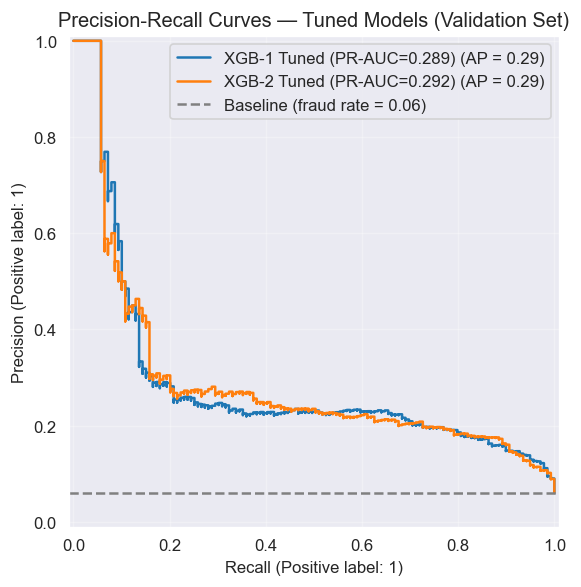

XGB-1 Tuned Val PR-AUC: 0.2892
XGB-2 Tuned Val PR-AUC: 0.2923

Winner: XGB-2 Tuned (random oversampling)
Threshold applied to test set: 0.60


In [45]:
best_t_xgb2 = 0.60
best_f1_2 = 0.316
fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_xgb1_tuned,
    name=f"XGB-1 Tuned (PR-AUC={xgb1_tuned_val_prauc:.3f})", ax=ax
)
PrecisionRecallDisplay.from_predictions(
    y_val, y_val_proba_xgb2_tuned,
    name=f"XGB-2 Tuned (PR-AUC={xgb2_tuned_val_prauc:.3f})", ax=ax
)
fraud_rate = y_val.mean()
ax.axhline(fraud_rate, color="gray", linestyle="--", label=f"Baseline (fraud rate = {fraud_rate:.2f})")
ax.set_title("Precision-Recall Curves — Tuned Models (Validation Set)")
ax.legend(loc="upper right"); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show() 
# Select winner by val PR-AUC
if xgb1_tuned_val_prauc >= xgb2_tuned_val_prauc:
    best_model_tuned  = xgb1_tuned
    best_thresh_tuned = best_t_xgb1
    winner_label      = "XGB-1 Tuned (no resampling)"
else:
    best_model_tuned  = xgb2_tuned
    best_thresh_tuned = best_t_xgb2
    winner_label      = "XGB-2 Tuned (random oversampling)"
 
print(f"XGB-1 Tuned Val PR-AUC: {xgb1_tuned_val_prauc:.4f}")
print(f"XGB-2 Tuned Val PR-AUC: {xgb2_tuned_val_prauc:.4f}")
print(f"\nWinner: {winner_label}")
print(f"Threshold applied to test set: {best_thresh_tuned:.2f}")
 

"""
### Final Evaluation on Test Set
 
The test set is used **once** here, with the threshold chosen on validation.
This is the only place test set predictions appear in the notebook.
"""

=== XGB-2 Tuned (random oversampling) — TEST SET RESULTS ===
PR-AUC:    0.2461
ROC-AUC:   0.8653
Precision: 0.2211
Recall:    0.6377
F1-score:  0.3284
Threshold: 0.60

Confusion Matrix:
[[1865  310]
 [  50   88]]
  TN=1865  FP=310
  FN=50  TP=88


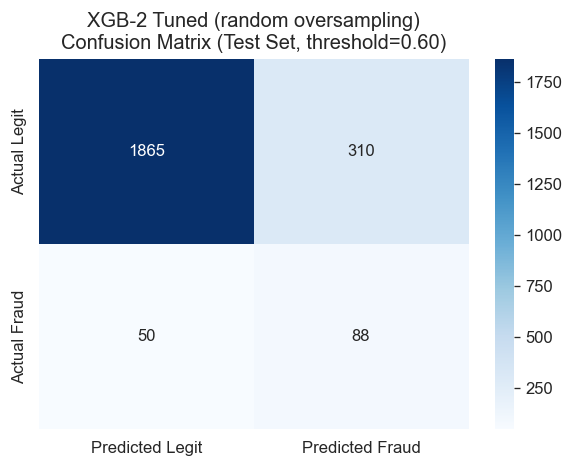

In [46]:
y_test_proba_winner  = best_model_tuned.predict_proba(X_test)[:, 1]
y_test_pred_winner   = (y_test_proba_winner >= best_thresh_tuned).astype(int)
 
test_prauc  = average_precision_score(y_test, y_test_proba_winner)
test_rocauc = roc_auc_score(y_test, y_test_proba_winner)
test_prec   = precision_score(y_test, y_test_pred_winner, zero_division=0)
test_rec    = recall_score(y_test, y_test_pred_winner, zero_division=0)
test_f1     = f1_score(y_test, y_test_pred_winner, zero_division=0)
test_cm     = confusion_matrix(y_test, y_test_pred_winner)
 
print(f"=== {winner_label} — TEST SET RESULTS ===")
print(f"PR-AUC:    {test_prauc:.4f}")
print(f"ROC-AUC:   {test_rocauc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-score:  {test_f1:.4f}")
print(f"Threshold: {best_thresh_tuned:.2f}")
print(f"\nConfusion Matrix:\n{test_cm}")
print(f"  TN={test_cm[0,0]}  FP={test_cm[0,1]}")
print(f"  FN={test_cm[1,0]}  TP={test_cm[1,1]}")
 
import seaborn as sns
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Legit","Predicted Fraud"],
            yticklabels=["Actual Legit","Actual Fraud"], ax=ax)
ax.set_title(f"{winner_label}\nConfusion Matrix (Test Set, threshold={best_thresh_tuned:.2f})")
plt.tight_layout(); plt.show()

In [47]:
summary = pd.DataFrame([
    {"Model": "XGB-1 Default (no resamp.)", "Val PR-AUC": 0.2779, "Val Recall@0.5": 0.820, "Val Precision@0.5": 0.176, "Threshold": 0.50},
    {"Model": "XGB-2 Default (rand. oversamp.)", "Val PR-AUC": 0.25,  "Val Recall@0.5": 0.840, "Val Precision@0.5": 0.160, "Threshold": 0.50},
    {"Model": "XGB-1 Tuned",  "Val PR-AUC": 0.2892, "Val Recall@0.5": None, "Val Precision@0.5": None, "Threshold": 0.55},
    {"Model": "XGB-2 Tuned ✓ WINNER", "Val PR-AUC": 0.2923, "Val Recall@0.5": None, "Val Precision@0.5": None, "Threshold": 0.60},
])
print("=== XGBoost Model Comparison ===")
print(summary.to_string(index=False))
print(f"\nFinal test set (winner — XGB-2 Tuned):")
print(f"  PR-AUC={test_prauc:.4f}  ROC-AUC={test_rocauc:.4f}  Precision={test_prec:.4f}  Recall={test_rec:.4f}  F1={test_f1:.4f}")

=== XGBoost Model Comparison ===
                          Model  Val PR-AUC  Val Recall@0.5  Val Precision@0.5  Threshold
     XGB-1 Default (no resamp.)      0.2779            0.82              0.176       0.50
XGB-2 Default (rand. oversamp.)      0.2500            0.84              0.160       0.50
                    XGB-1 Tuned      0.2892             NaN                NaN       0.55
           XGB-2 Tuned ✓ WINNER      0.2923             NaN                NaN       0.60

Final test set (winner — XGB-2 Tuned):
  PR-AUC=0.2461  ROC-AUC=0.8653  Precision=0.2211  Recall=0.6377  F1=0.3284
